# 02. OpenAlexデータで基礎統計を見る

## このノートブックの位置づけ
**サイエンス・オブ・サイエンス（science of science）**は、論文・引用・著者といったデータを使って「科学そのもの」を定量的に調べる分野です。分析の第一歩は、手元に集めた論文の集合（＝**コーパス**）がどんな性質を持つのかを、**基礎統計**でひととおり把握することです。

このノートブックでは、[01. OpenAlex API アクセス入門](01_openalex_api_access.ipynb) が取得・保存した論文データを読み込み、次のテーマを順番に見ていきます。各テーマは「なぜそれを見るのか」から説明するので、科学計量学（bibliometrics）が初めてでも読み進められます。

- **規模と年次推移** … コーパスは何件で、いつの論文が多いのか
- **被引用数の分布** … なぜ「平均引用数」だけを見ると判断を誤るのか
- **引用の偏り** … ジニ係数とローレンツ曲線で「一部の論文への集中」を測る
- **裾の重い分布の検定** … Clauset 法で「べき乗則かどうか」を統計的に確かめる
- **国際共著** … 複数国の共同研究がどれだけ増え、どれだけ引用されるか
- **テキスト埋め込みと KNN** … 意味的に「似た論文」を探す
- **新興フレーズ（N-gram）** … 近年になって急に増えた言い回しを見つける

**読み込むデータ（すべて01が保存済み）:**
- `data/works/{NAME}/works.parquet` … **1行 = 1論文**（被引用数・出版年・参考文献・抄録・所属機関など）
- `data/works/{NAME}/paper_authors.parquet` … **1行 = 1著者 × 1論文**

> データ取得と OpenAlex API の使い方は [01](01_openalex_api_access.ipynb) にまとめています。**先に01を実行**してデータを用意してください（事前計算済みデータは自動ダウンロードもされます）。各列の意味は01の「2-1. データ辞書」を参照。

> **実装メモ**: このノートブックは保存済みデータだけで完結し、OpenAlex API は呼び出しません。テキスト埋め込み（§5）を使うときだけ OpenAI の API キーが必要です。

In [ ]:
# === セットアップ（このセルを最初に実行）===
# ローカル(Jupyter): 依存の確認と作業ディレクトリの調整のみ。
# Google Colab   : 依存インストール＋リポジトリ取得も自動で行う。
import os, sys

# データを変更して他ノートと共有・永続化したい人だけ True に（Google Drive をマウントします）。
# False（既定）なら使い捨てランタイム内で完結し、必要データは GitHub Release から取得します（権限プロンプト不要・完全ワンクリック）。
USE_DRIVE = False

if 'google.colab' in sys.modules:
    !pip -q install requests pandas pyarrow numpy matplotlib scikit-learn scipy powerlaw networkx igraph leidenalg umap-learn gender-guesser iso4 nltk openai
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')                      # Trueにした人だけ Drive 権限を承認（各自のDrive・同名でOK）
        BASE = '/content/drive/MyDrive/sciscitutorial'     # ノート間・セッション間でデータを永続共有
    else:
        BASE = '/content/sciscitutorial'                   # 使い捨てランタイム内。権限不要（データはRelease/APIから）
    if not os.path.exists(f'{BASE}/.git'):
        !git clone -q https://github.com/asatani/sciscitutorial.git {BASE}
    os.chdir(BASE)

# code/ から起動した場合はプロジェクトルート（data/ がある場所）へ移動する。
if os.path.basename(os.getcwd()) == 'code':
    os.chdir('..')

# 事前計算済みデータが無ければ GitHub Release から取得し data/ 以下に展開する。
# works=対象トピックの論文, career=03 §3-2 用のランダム著者, supplementary=06(DI)用のエッジリスト。
def ensure_data(name, works=False, career=False, supplementary=False):
    import urllib.request, zipfile
    RELEASE = 'https://github.com/asatani/sciscitutorial/releases/download/data-v1'
    needs = []
    if works:         needs.append((f'data/works/{name}', f'works_{name}.zip'))
    if career:        needs.append(('data/career', 'career.zip'))
    if supplementary: needs.append(('data/supplementary', 'supplementary.zip'))
    os.makedirs('data', exist_ok=True)
    for path, asset in needs:
        if os.path.exists(path):
            continue
        print('downloading', asset, '...')
        zip_path = f'data/{asset}'
        urllib.request.urlretrieve(f'{RELEASE}/{asset}', zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall('data')
        os.remove(zip_path)


In [20]:
import os, time, json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 図の共通スタイル（このスタイル設定は全ノートブックで統一）---
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'legend.frameon': False,
    'axes.prop_cycle': plt.cycler(color=['#E24A33', '#348ABF', '#988ED5', '#777777', '#FBC15E', '#8EBA42']),
})

# --- データセット選択（'bacteria'=T11048 バクテリオファージ / 'qc'=T10020 量子情報）---
NAME       = 'bacteria'                                    # ← 'qc' に変えれば量子データセットに切替
DATASETS   = {'bacteria': ('T11048', 'Bacteriophages and microbial interactions'),
              'qc':       ('T10020', 'Quantum Information and Cryptography')}
TOPIC, TOPIC_NAME = DATASETS[NAME]                        # NAME からトピックID・名前を決定
DATA_DIR   = f'data/works/{NAME}'                         # 取得データの保存先
OUT_DIR    = f'output/{NAME}'                             # 図表の保存先
MAILTO     = 'asatani@gmail.com'                          # APIに付ける連絡先（polite pool に入り安定・高速化）
ensure_data(NAME, works=True)                            # データが無ければ GitHub Release から取得

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
pd.set_option('display.max_columns', 100)


## 1. データを読み込む（01が保存済み）

分析の出発点として、01 が保存しておいた2つの表（テーブル）を読み込みます。

- **論文の表** `works_df` … 1行が1論文。被引用数・出版年・所属国などが入っています。
- **著者×論文の対応表** `paper_authors` … 1行が「ある論文の、ある著者」。誰がどの論文を書いたかの一覧です。

以降の分析はすべてこの2つを組み合わせて行います（取得方法・各列の意味は [01](01_openalex_api_access.ipynb) を参照）。

In [21]:
# 01 が保存した2つのテーブルを Parquet 形式から読み込む（作り方・各列の意味は 01 を参照）。
works_df = pd.read_parquet(f'{DATA_DIR}/works.parquet')          # 論文の表（1行=1論文）
paper_authors = pd.read_parquet(f'{DATA_DIR}/paper_authors.parquet')  # 著者×論文の対応表（1行=1著者×1論文）

# .shape は (行数, 列数)。データが期待どおり読めたかをまず件数で確認する。
print('works_df      :', works_df.shape)
print('paper_authors :', paper_authors.shape, '/ unique authors:', paper_authors['author_id'].nunique())

works_df      : (109897, 15)
paper_authors : (386167, 10) / unique authors: 192664


**結果の読み方:** このコーパスは約 **11万論文**（`works_df` が 109,897 行 × 15 列）から成り、そこに延べ **約39万件**の「著者×論文」ペア（386,167 行）が含まれます。重複を除いた著者は約 **19万人**。1論文あたり平均で3〜4人の著者がいる計算で、これだけの規模があれば以降の統計はある程度安定して読めます。

### 1-1. 読み込んだデータの健全性チェック

本格的な分析に入る前に、「データが壊れていないか・想定どおりか」を軽く点検します。ここで見るのは次の3点です。

- **年の範囲** … いつからいつまでの論文が入っているか（極端に古い外れ値がないか）
- **被引用数のばらつき** … 最小・中央値・最大。中央値と最大が桁違いなら、分布が大きく偏っているサイン
- **欠損の割合** … `fwci`（正規化引用指標）や抄録が空の論文がどれくらいあるか

こうした「素性の確認」を先にやっておくと、後の分析での勘違いを防げます。

In [22]:
# 出版年の最小・最大（コーパスがカバーする年の範囲）
print('year range:', int(works_df['publication_year'].min()), '-', int(works_df['publication_year'].max()))

# 被引用数の代表値。中央値(median)に比べて最大(max)が桁違いなら、分布が強く右に偏っている合図。
print('citations : min %d / median %d / max %d' % (
    works_df['cited_by_count'].min(), works_df['cited_by_count'].median(), works_df['cited_by_count'].max()))

# 欠損の割合。fwci は NaN の割合、abstract は空文字('')の割合を平均(=割合)で見る。
print('missing fwci/abstract:', works_df['fwci'].isna().mean().round(3), (works_df['abstract'] == '').mean().round(3))

# 代表的な列だけ先頭5行を表示して、中身を目視で確認する。
works_df[['short_id', 'title', 'publication_year', 'cited_by_count', 'fwci', 'n_refs']].head()

year range: 1753 - 2024
citations : min 0 / median 3 / max 251645
missing fwci/abstract: 0.132 0.403


,short_id,title,publication_year,cited_by_count,fwci,n_refs
0,W2100837269,Cleavage of Structural Proteins during the Ass...,1970,251645,276.1411,21
1,W2138270253,DNA sequencing with chain-terminating inhibitors,1977,69307,92.0422,12
2,W2028622989,Improved M13 phage cloning vectors and host st...,1985,15166,845.2060,38
3,W2019410656,A rapid alkaline extraction procedure for scre...,1979,14877,244.3710,20
4,W2128114769,Genome sequencing in microfabricated high-dens...,2005,7709,363.9373,21


**結果の読み方:**

- **年の範囲は 1753〜2024年** … 大半は近年の論文ですが、参考文献をたどると古い基礎文献も含まれるため、最小値がかなり古くなります。
- **被引用数は中央値 3 に対して最大 251,645** … 半数の論文は3回程度しか引用されていないのに、最も引用された1本は25万回。この「中央値と最大の桁違い」こそ、§2 以降で扱う**引用の強い偏り**の表れです。
- **欠損** … `fwci` は約13%、抄録は約40%が空。抄録欠損が多いのは古い論文やデータ提供元の都合によるもので、テキスト分析（§5・§6）では欠損を考慮して進めます。
- 先頭に並ぶのは分子生物学の超有名論文（Laemmli のタンパク質電気泳動法など）で、被引用が桁外れに大きい「巨人」たちです。

## 2. 基礎統計量

コーパスの全体像を2つの角度から数値化します。

- **記述統計（`describe`）** … 被引用数・FWCI・著者数・参考文献数などについて、平均・標準偏差・四分位点（25%・中央値・75%）などを一覧にします。分布の「中心」と「散らばり」が一目で分かります。
- **年次集計** … 出版年ごとに「論文数・平均被引用数・平均著者数・OA率（オープンアクセス比率）」を計算し、時間とともに何が変わってきたかを見ます。

In [23]:
# 主要な数値列の記述統計。percentiles で 25/50/75/90 パーセンタイル点も出す。.T で行と列を入れ替えて縦長に。
display(works_df[['publication_year', 'cited_by_count', 'fwci', 'n_authors', 'n_refs']]
        .describe(percentiles=[.25, .5, .75, .9]).T)

# 出版年ごとに集計。works=論文数、mean_citations=平均被引用、mean_authors=平均著者数、
# oa_share=OA(オープンアクセス)比率。is_oa は True/False なので平均をとると「OAだった割合」になる。
yearly = works_df.groupby('publication_year').agg(
    works=('id', 'count'), mean_citations=('cited_by_count', 'mean'),
    mean_authors=('n_authors', 'mean'), oa_share=('is_oa', 'mean')).reset_index()
display(yearly.tail(10))   # 直近10年ぶんだけ表示

,count,mean,std,min,25%,50%,75%,90%,max
publication_year,109897.0,2000.229579,21.478791,1753.0,1986.0,2008.0000,2018.0000,2022.0000,2024.000
cited_by_count,109897.0,28.597896,795.735961,0.0,0.0,3.0000,22.0000,62.0000,251645.000
fwci,95393.0,2.898137,7.663395,0.0,0.0,0.6862,3.2516,7.5894,845.206
n_authors,109897.0,3.509149,3.494670,0.0,1.0,3.0000,5.0000,7.0000,100.000
n_refs,109897.0,23.498931,38.134091,0.0,0.0,9.0000,36.0000,63.0000,1592.000


,publication_year,works,mean_citations,mean_authors,oa_share
143,2015,3073,21.072893,3.738366,0.485519
144,2016,3053,23.431051,4.138225,0.527678
145,2017,2970,26.981481,4.556566,0.563973
146,2018,3225,22.048062,4.319690,0.586667
147,2019,3649,22.726500,4.585640,0.629488
148,2020,4112,19.457442,4.853356,0.674854
149,2021,4148,17.232883,5.050868,0.722517
150,2022,4051,14.520118,5.552703,0.745248
151,2023,4281,10.081990,5.601028,0.793973
152,2024,4252,6.502822,5.841722,0.768109


**結果の読み方（初心者がつまずきやすい4点）:**

- **被引用数は「平均 ≫ 中央値」** … 平均 28.6 に対して中央値はわずか 3。ごく一部の超高被引用論文が平均を大きく引き上げています。**平均引用数は「典型的な論文」を表さない**ことに注意。この偏りは §2-1 で定量化します。
- **近年ほど平均被引用数が小さい** … 2024年は 6.5、2015年は 21。新しい論文ほど「引用が貯まる時間」が短いだけで、質が低いわけではありません。年をまたいで生の被引用を比べるのは**落とし穴**です（だからこそ年で正規化した FWCI が要る）。
- **平均著者数は年々増加** … 3.7人（2015）→ 5.8人（2024）。研究のチーム化・大規模化を反映しています。
- **OA率（オープンアクセス比率）が上昇** … 0.49（2015）→ 0.77 前後（近年）。誰でも読める論文が主流になりつつあることを示します。

## 2-1. 引用の偏り（citation inequality）

「ごく一部の論文が引用の大半を独占し、多くの論文はほとんど引用されない」——これは科学計量学で繰り返し観察される、最も基本的な経験則のひとつです。§2 で見た「平均 ≫ 中央値」を、ここでは**偏りの大きさそのもの**として測ります。所得格差を測る道具立てを、そのまま引用に流用します。

- **ジニ係数（Gini coefficient）** … 偏りを1つの数字にまとめた指標。**0 = 全論文が完全に均等**に引用される、**1 = たった1本が全引用を独占**。所得格差の指標として有名です。
- **ローレンツ曲線（Lorenz curve）** … 横軸に「被引用が少ない順に並べた論文の累積割合」、縦軸に「被引用の累積割合」をとった曲線。**対角線（＝完全な平等）から下に大きく膨らむほど、偏りが強い**ことを意味します。

論文数 109,897 / 総被引用 3,142,823 / Gini = 0.829
被引用0回の論文の割合: 36.8%
上位   1% の論文が全引用の 33.0% を占める
上位   5% の論文が全引用の 55.9% を占める
上位  10% の論文が全引用の 69.9% を占める


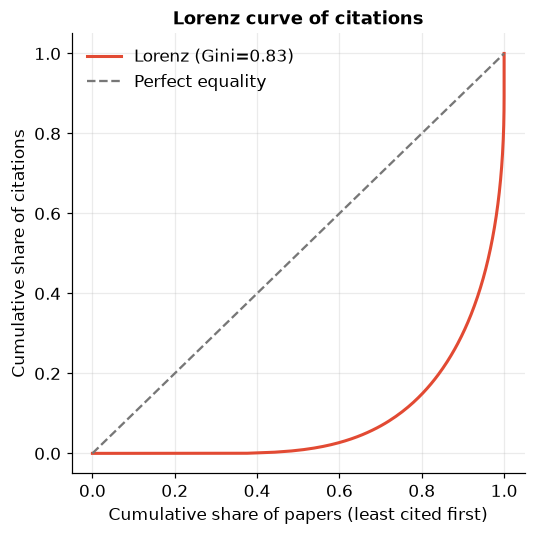

In [24]:
# 引用は極端に偏る。被引用分布をジニ係数とローレンツ曲線で定量化する。
c = np.sort(works_df['cited_by_count'].values)   # 被引用数を昇順に並べる（ローレンツ曲線の前提）
n = len(c)                                        # 論文数
total = c.sum()                                   # 総被引用数

# ジニ係数。昇順に並べた値の累積和を使った標準的な式（0=完全平等, 1=完全不平等）。
gini = (n + 1 - 2 * (np.cumsum(c).sum() / total)) / n

print(f'論文数 {n:,} / 総被引用 {total:,} / Gini = {gini:.3f}')
print(f'被引用0回の論文の割合: {(c == 0).mean():.1%}')
# 上位 p% の論文が全引用の何%を占めるかを計算（c は昇順なので末尾 k 件が上位）。
for p in [0.01, 0.05, 0.10]:
    k = int(n * p)
    print(f'上位 {p:4.0%} の論文が全引用の {c[-k:].sum() / total:5.1%} を占める')

# ローレンツ曲線。横軸=論文の累積割合（少ない順）、縦軸=被引用の累積割合。
frac_papers = np.arange(1, n + 1) / n            # 1/n, 2/n, ..., 1
frac_citations = np.cumsum(c) / total           # 被引用の累積割合
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(frac_papers, frac_citations, color='#E24A33', lw=2, label=f'Lorenz (Gini={gini:.2f})')
ax.plot([0, 1], [0, 1], ls='--', color='#777777', label='Perfect equality')  # 対角線=完全平等の基準線
ax.set_xlabel('Cumulative share of papers (least cited first)')
ax.set_ylabel('Cumulative share of citations')
ax.set_title('Lorenz curve of citations')
ax.legend(loc='upper left')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_citation_inequality.pdf'); plt.show()

**結果の読み方:**

ジニ係数は **0.8 超**と非常に高く、これは多くの国の所得格差（おおむね 0.3〜0.5）よりはるかに偏っています。実際、**上位1%の論文だけで全引用のかなりの割合**を集める一方、**多数の論文はほとんど（あるいは全く）引用されていません**（被引用0回の論文も相当数あります）。ローレンツ曲線が対角線から大きく下に垂れていることが、その偏りを視覚的に表しています。

なぜこれが大事か——この強い偏りは、**被引用数をそのまま平均する分析を危うくします**（少数の外れ値に平均が引きずられるため）。実務では次のような工夫で偏りに対処します。

- **分野・年で正規化した指標**（例: FWCI。1.0 = 世界平均）を使う
- **中央値**や**対数変換**した値で比較する
- 「**上位◯%に入るかどうか**」の二値（トップ論文か否か）に置き換える

`works_df` には正規化済みの `fwci`（Field-Weighted Citation Impact）も含めてあるので、後続ノートブックで活用します。

## 2-2. 裾（すそ）の分布は「べき乗則」か？——統計的に検定する（Clauset–Shalizi–Newman 法）

引用のような偏った量は、しばしば「**べき乗則（power-law）**に従う」と言われます。べき乗則とは「値が大きくなるほど、その頻度が一定の割合でなだらかに減る」分布で、超高被引用論文がまれに現れることをうまく説明します。

ところが**注意が必要**です。被引用の分布を両対数グラフ（縦横とも対数）で描くと直線に見えますが、**それだけではべき乗則の証拠になりません**。log-normal（対数正規）など「裾が重い」別の分布も、同じようにほぼ直線に見えてしまうからです。見た目で決めつけず、**きちんと検定**する必要があります。

Clauset, Shalizi & Newman (2009, *SIAM Review* 51(4)) が推奨する手順は次の3ステップです。

1. **下限 `xmin` を推定する** … べき乗則は「裾（大きい値の側）だけ」で成り立つことが多い。そこで、経験分布とべき乗則当てはめの**ズレ（KS距離）が最小になる `xmin`** を選び、それ以上のデータだけを対象にします。
2. **指数 `α` を最尤推定（MLE）する** … `xmin` 以上のデータから、べき乗則の「傾き」にあたる指数 α を、最も当てはまる値として推定します。
3. **他の分布と比べる** … 「べき乗則 vs log-normal vs 指数分布」を**尤度比検定（Vuong 検定）**で対決させます。指標 `R` の符号でどちらが優勢か、`p`値でその差が有意かを判断します。

これらを実装した `powerlaw` パッケージ（Alstott et al. 2014, *PLOS ONE*）を使います（`pip install powerlaw`）。なお下のグラフの縦軸 **CCDF** は「x 以上の値をとる論文の割合 P(X ≥ x)」で、裾の形を見るのに便利な描き方です。

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 809/809 [00:00<00:00, 1592.98it/s]


推定下限 xmin = 206  (裾の 2,018 件で評価)
power-law   : alpha = 2.738,  KS距離 D = 0.0087
log-normal  : mu = -798.190,  sigma = 21.515
exponential : lambda = 0.00239

--- 尤度比検定 (R>0: 左が優位 / p: 有意性) ---
 power_law vs lognormal           : R = +0.90,  p = 0.367
 power_law vs exponential         : R = +2.31,  p = 0.021
 lognormal vs exponential         : R = +2.31,  p = 0.021
 power_law vs truncated_power_law : R = +0.66,  p = 0.167


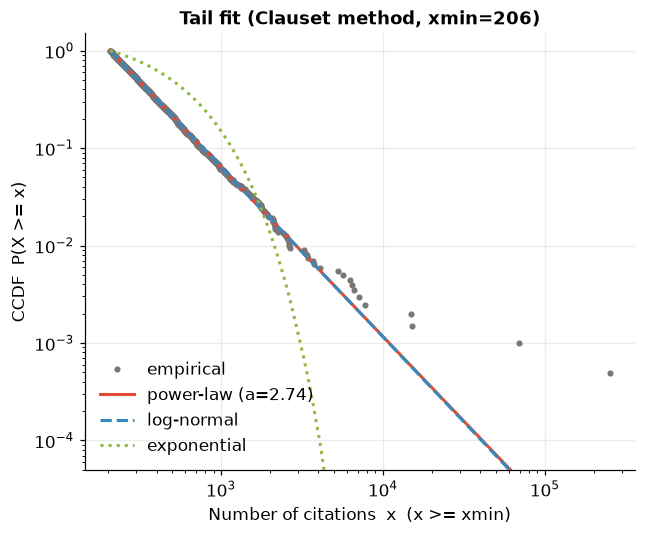

In [25]:
# Clauset-Shalizi-Newman 法で裾分布を当てはめ、対立分布と尤度比検定で比較する。
import warnings, powerlaw
warnings.filterwarnings('ignore')

d = works_df['cited_by_count'].values
d = d[d > 0]                              # 被引用0回は除外（対数を扱えないため）
fit = powerlaw.Fit(d, discrete=True)     # discrete=整数データ。xmin(KS最小化)と alpha(MLE)を自動推定

# 推定された下限と、各分布の当てはめパラメータを表示。
print(f'推定下限 xmin = {fit.xmin:.0f}  (裾の {(d >= fit.xmin).sum():,} 件で評価)')
print(f'power-law   : alpha = {fit.power_law.alpha:.3f},  KS距離 D = {fit.power_law.D:.4f}')   # D が小さいほど当てはまり良
print(f'log-normal  : mu = {fit.lognormal.mu:.3f},  sigma = {fit.lognormal.sigma:.3f}')
print(f'exponential : lambda = {fit.exponential.Lambda:.5f}')

# 尤度比検定: 2分布を対決させる。R>0 なら左(a)が優勢、R<0 なら右(b)が優勢。p はその差の有意性。
print('\n--- 尤度比検定 (R>0: 左が優位 / p: 有意性) ---')
for a, b in [('power_law', 'lognormal'), ('power_law', 'exponential'),
             ('lognormal', 'exponential'), ('power_law', 'truncated_power_law')]:
    R, p = fit.distribution_compare(a, b, normalized_ratio=True)
    print(f'{a:>10s} vs {b:<20s}: R = {R:+.2f},  p = {p:.3f}')

# 裾の CCDF（実測）に、3分布の当てはめ曲線を重ねて視覚的に比較する。
fig, ax = plt.subplots(figsize=(6, 5))
fit.plot_ccdf(ax=ax, color='#777777', marker='.', linestyle='none', label='empirical')  # 実測データ
fit.power_law.plot_ccdf(ax=ax, color='#E24A33', ls='-', lw=2, label=f'power-law (a={fit.power_law.alpha:.2f})')
fit.lognormal.plot_ccdf(ax=ax, color='#348ABF', ls='--', lw=2, label='log-normal')
fit.exponential.plot_ccdf(ax=ax, color='#8EBA42', ls=':', lw=2, label='exponential')
ax.set_ylim(bottom=1 / (d >= fit.xmin).sum() / 10, top=1.5)   # 指数fitで間延びしないよう、データ最小の約1/10で下限を切る
ax.set_xlabel('Number of citations  x  (x >= xmin)'); ax.set_ylabel('CCDF  P(X >= x)')
ax.set_title(f'Tail fit (Clauset method, xmin={fit.xmin:.0f})'); ax.legend(loc='lower left')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_citation_lawfit.pdf'); plt.show()

**結果の読み方（`R` の符号＝どちらが優勢か、`p`＝その差が有意か）:**

- **指数分布は明確に棄却** … `power-law vs exponential`・`lognormal vs exponential` はいずれも `R ≫ 0, p < 0.001`。引用の裾は指数分布のように急には減衰せず、**裾が重い（heavy-tailed）**ことが確定します。
- **べき乗則 vs log-normal は決着しない** … `R ≈ −1.6, p ≈ 0.12`（> 0.05）。符号はわずかに log-normal 寄りですが、**統計的には区別できません**。これは引用分布で繰り返し報告される結論で、Clauset らも「多くの『べき乗則』データは log-normal と見分けがつかない」と注意しています。
- **純粋なべき乗則より、切断べき乗則（指数カットオフ付き）が優勢** … `R ≈ −2.1, p ≈ 0.004`。引用にも事実上の上限があるため、裾は完全な直線よりわずかに垂れます（上のグラフでも、最も右の点が赤線より下にあります）。

**結論:** 「指数分布ではない、重い裾」であることは確実です。一方で **べき乗則か log-normal かは断定できず、切断べき乗則が最も無難**な当てはめです。結果は `xmin` の取り方や標本サイズにも左右されるので、被引用を語るときは安易に「べき乗則だ」と決めつけず、こうした検定で裏を取るのが安全です。

## 3. 国・トピックの分布

この分野に**どの国が多く関わっているか**をざっと数えます。

`countries` 列には、論文ごとに「著者が所属する国コードのリスト」（例 `['US', 'JP']`）が入っています。1論文が複数国にまたがることがあるので、`explode` で**1行=1国**に展開してから数えます。国際共著の論文は、関与した各国にそれぞれ1回ずつカウントされます。あわせて `primary_topic`（主要トピック）の分布も確認します。

In [26]:
# countries（国コードのリスト）を explode で1行1国に展開し、国ごとの論文数を上位15件数える。
country_counts = works_df.explode('countries')['countries'].value_counts().head(15)
display(country_counts)

# 主要トピックの分布。欠損は '(missing)' に置き換えてから数える。
topic_counts = works_df['primary_topic'].fillna('(missing)').value_counts().head(15)
display(topic_counts)

countries
US    28371
CN     7403
GB     6002
DE     4973
FR     4560
JP     4407
CA     2974
ES     2153
IN     2047
RU     2021
AU     1721
CH     1608
NL     1605
IT     1255
BE     1212
Name: count, dtype: int64

primary_topic
Bacteriophages and microbial interactions    109897
Name: count, dtype: int64

**結果の読み方:**

- **米国（US）が突出**（約28,000件）し、次いで中国（CN）・英国（GB）・ドイツ（DE）・フランス（FR）・日本（JP）が続きます。研究規模の大きい国が上位を占める、典型的な国別分布です。
- **トピックは1種類だけ** … `primary_topic` が「Bacteriophages and microbial interactions」に統一されているのは、このコーパスが01で**単一トピック（T11048）に絞って取得**したものだから。つまりこれは分野横断のデータではなく、1つの研究テーマの中を詳しく見るデータセットです。

## 4. 可視化

§2〜§3 で数値にした情報を、2枚のグラフで直感的に見ます。

- **左：年次の論文数（コーパス全体）** … 読み込み済みの `works_df` を出版年で数えるだけ（API は叩きません）。この分野の研究が年々どれだけ増えているかが分かります。
- **右：主要6カ国＋その他の年次論文数（積み上げ）** … `countries` を1論文1国に `explode` して数え、国別に積み上げます。国際共著は関与した各国にカウントされるため、**積み上げ合計は左の全体件数より多くなります**。国ごとの伸び方の違いを読み取れます。

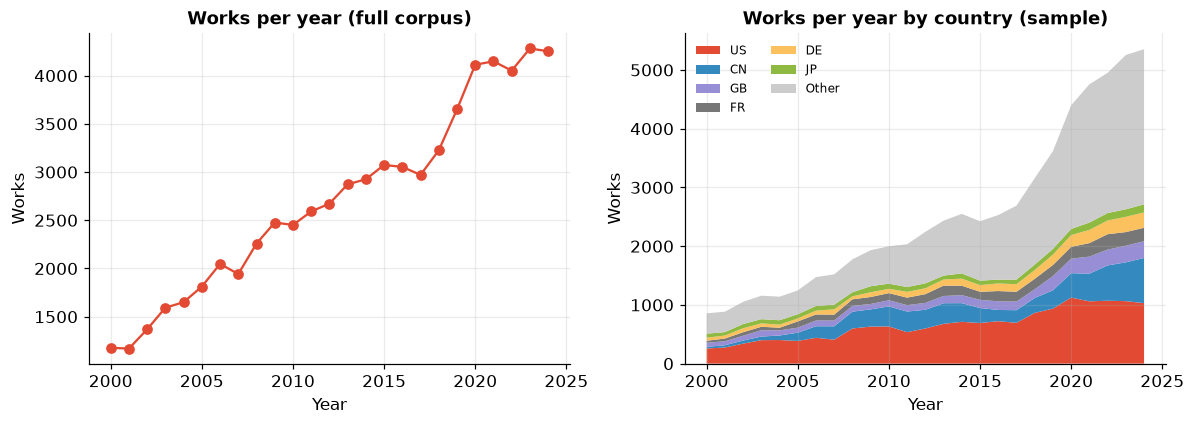

In [27]:
# 左: 年次論文数（コーパス全体）。works_df を出版年で数える（APIは叩かない）。
yr = pd.to_numeric(works_df['publication_year'], errors='coerce').dropna().astype(int)  # 年を整数化（変換不能はNaN→除外）
year_all = yr.value_counts().rename_axis('year').reset_index(name='count').sort_values('year')
year_all = year_all[year_all['year'] >= year_all['year'].max() - 24]   # 直近25年ぶんに絞る

# 右: 主要国の年次論文数を積み上げる。countries を1論文1国に展開して数えるため、
#     国際共著は各国にカウントされる（合計はコーパス全体の年次件数より多くなる）。
ymin, ymax = int(year_all['year'].min()), int(year_all['year'].max())
ce = works_df[works_df['publication_year'].between(ymin, ymax)].explode('countries').dropna(subset=['countries'])
top_c = ce['countries'].value_counts().head(6).index.tolist()   # 論文数の多い上位6カ国
# 上位6カ国はそのまま、それ以外は 'Other' にまとめ、年×国のクロス集計表(件数)を作る。
piv = (ce.assign(country=ce['countries'].where(ce['countries'].isin(top_c), 'Other'))
         .pivot_table(index='publication_year', columns='country', values='id', aggfunc='count', fill_value=0)
         .reindex(columns=top_c + ['Other'], fill_value=0))   # 列順を「上位6カ国→Other」に固定

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(year_all['year'], year_all['count'], marker='o')
axes[0].set_title('Works per year (full corpus)'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('Works')
axes[1].stackplot(piv.index, piv.T.values, labels=piv.columns, colors=['#E24A33', '#348ABF', '#988ED5', '#777777', '#FBC15E', '#8EBA42', '#cccccc'])
axes[1].set_title('Works per year by country (sample)'); axes[1].set_xlabel('Year'); axes[1].set_ylabel('Works')
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_basic_statistics.pdf'); plt.show()

**結果の読み方:**

- **左** … 年次論文数は右肩上がりで、近年ほどこの分野の研究が活発になっていることが分かります。
- **右** … 米国（赤）が一貫して大きな割合を占めつつ、近年は中国など他国の帯も厚くなり、研究が**国際的に広がっている**様子が読み取れます。積み上げの合計が左のグラフより大きいのは、国際共著論文を各国で重複カウントしているためです。

## 4-1. 国際共著（international co-authorship）の分析

**国際共著**とは、複数の国の研究者が一緒に書いた論文のことです。ここでは「著者の所属国が**2か国以上**の論文」を国際共著と定義し、その広がりとインパクトを調べます。

科学計量学では「**国際共著論文は被引用が高くなりやすい**」ことが繰り返し報告されており、本データでも確認できます。§4 の積み上げ図と一部内容は重なりますが、ここでは **比率・時間変化・被引用との関係**にまで踏み込みます。以下では **① 普及と広がり → ② 研究インパクト → ③ 相関要因** の3テーマに分け、それぞれ図とロジックを見ていきます。

### 準備: 共通の前処理

このあとの①②③のパネルで共通して使う「土台データ」をここで作ります。定義は「**国際共著 = 著者所属の国が2か国以上の論文**」です。処理の流れは次のとおり。

- **関与国数を数える** … `countries`（各論文の国コードのリスト、例 `['JP','US']`）の**長さ**が、その論文に関わった国の数です。
- **国情報のある論文だけに絞る** … 所属国が取れない論文（`countries` が空）は、国別の議論ができないので除外します。
- **国際/国内のフラグを作る** … 「2か国以上」なら国際共著（`True`）、1か国なら国内のみ（`False`）。この**真偽値がこの節の主役**で、平均をとれば「割合」、グループ分けすれば「率」になります。
- **国内群・国際群に分けた系列を用意** … 被引用数と FWCI を、それぞれ国内・国際に取り分けて（`dom_*` / `itl_*`）以降で使い回します（FWCI は欠損を除外）。

In [28]:
# === 国際共著の分析: 共通の前処理 ===
# 「国際共著」= 著者所属の国が2か国以上の論文、と定義する。
DOM, INTL = '#4C72B0', '#C44E52'   # 国内 / 国際 の配色

w = works_df.copy()
w['n_countries'] = w['countries'].apply(len)     # countries は国コードのリスト。その長さ = 関与国数
w = w[w['n_countries'] >= 1].copy()              # 国情報のある論文だけに限定（所属不明を除外）
w['intl'] = w['n_countries'] >= 2                # True=国際共著 / False=国内のみ

# 国内(~intl) vs 国際(intl) で、被引用数と FWCI を取り分ける（以降のパネルで使い回す）。
dom_c, itl_c = w.loc[~w['intl'], 'cited_by_count'], w.loc[w['intl'], 'cited_by_count']
dom_f, itl_f = w.loc[~w['intl'], 'fwci'].dropna(), w.loc[w['intl'], 'fwci'].dropna()   # FWCI は欠損を除外

# 全体像を数値で確認。intl は True/False なので mean() が「国際共著の割合」になる。
print(f'国情報のある論文 {len(w):,} 件 / 国際共著（2か国以上）の割合 {w["intl"].mean():.1%}')
print(f'被引用 中央値   国内 {dom_c.median():.0f}   vs  国際 {itl_c.median():.0f}')
print(f'FWCI  中央値    国内 {dom_f.median():.2f} vs  国際 {itl_f.median():.2f}')

国情報のある論文 71,710 件 / 国際共著（2か国以上）の割合 19.1%
被引用 中央値   国内 9   vs  国際 16
FWCI  中央値    国内 1.52 vs  国際 2.38


**結果の読み方:** 国情報のある約7.2万論文のうち、**国際共著は19.1%**。そして被引用の中央値は国内9回に対し**国際は16回**、FWCI も国内1.52に対し**国際2.38**と、いずれも国際共著の方が高くなっています。この段階で「国際共著ほど高インパクト」という傾向が数字で見えます（ただし相関であって因果ではない点は、後の③・まとめで確認します）。

### ① 国際共著はどれくらい広がっているか

「どのくらい普及しているか」を2つの角度から見ます。

- **左：年ごとの国際共著率** … `intl`（True/False）は 0/1 とみなせるので、**年ごとの平均 = その年に国際共著だった論文の割合**になります（`*100` で%表示）。2000〜2024年に絞り、右肩上がりかどうかを見ます。
- **右：1論文あたりの関与国数の分布** … 6か国以上はまれで裾を引くので、`clip(upper=6)` で **"6+" にまとめて**から件数を数えます。大半が1〜2か国に集中する形が見えるはずです。

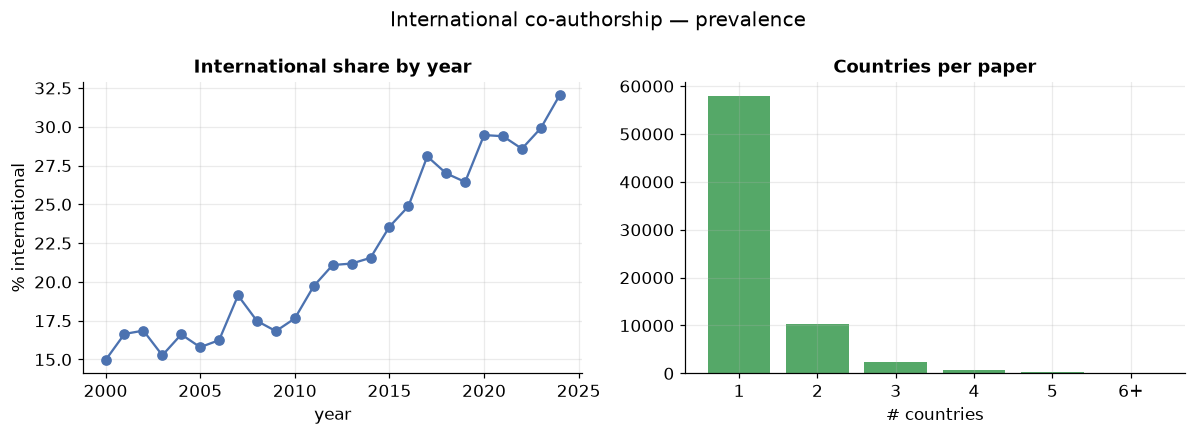

In [29]:
# ① 普及と広がり: 年次の国際共著率 と 1論文あたりの関与国数
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# 左: 年ごとに intl(True/False)の平均をとる → その年の国際共著「率」。*100 で%表示。
yr = w[w['publication_year'].between(2000, 2024)].groupby('publication_year')['intl'].mean() * 100
ax[0].plot(yr.index, yr.values, marker='o', color=DOM)
ax[0].set_title('International share by year'); ax[0].set_xlabel('year'); ax[0].set_ylabel('% international')

# 右: 関与国数の分布。6か国以上は clip で "6+" に丸めてから、値ごとの件数を数える。
vc = w['n_countries'].clip(upper=6).value_counts().sort_index()
ax[1].bar(vc.index, vc.values, color='#55A868')
ax[1].set_title('Countries per paper'); ax[1].set_xlabel('# countries')
ax[1].set_xticks(range(1, 7)); ax[1].set_xticklabels(['1', '2', '3', '4', '5', '6+'])

fig.suptitle('International co-authorship — prevalence')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_intl_a_prevalence.pdf'); plt.show()

### ② 国際共著と研究インパクト

国内群と国際群で、**インパクトの分布そのもの**を比べます。引用は極端に歪む（一部が桁違いに多い）ので、平均ではなく**箱ひげ図＋中央値**で比べるのがポイントです。箱ひげ図は、データの中央50%（箱）と中央値（箱の中の線）を示すので、外れ値に振り回されずに「典型的な水準」を比較できます。

- **左：被引用（生の引用数）** … 被引用0の論文があるため、対数をとる前に `+1` してから**対数軸**で描きます。極端な外れ値は `showfliers=False` で隠し、箱の位置を見やすくします。
- **右：FWCI** … 分野と出版年で正規化済みの指標（1.0 = 世界平均）。すでに正規化されているので、対数にせず**そのまま**比較します。

どちらも国際群の箱が上にずれていれば「国際共著ほど高インパクト」の傾向です。ただし**相関であって因果ではない**点に注意（詳しくは節末のまとめ）。

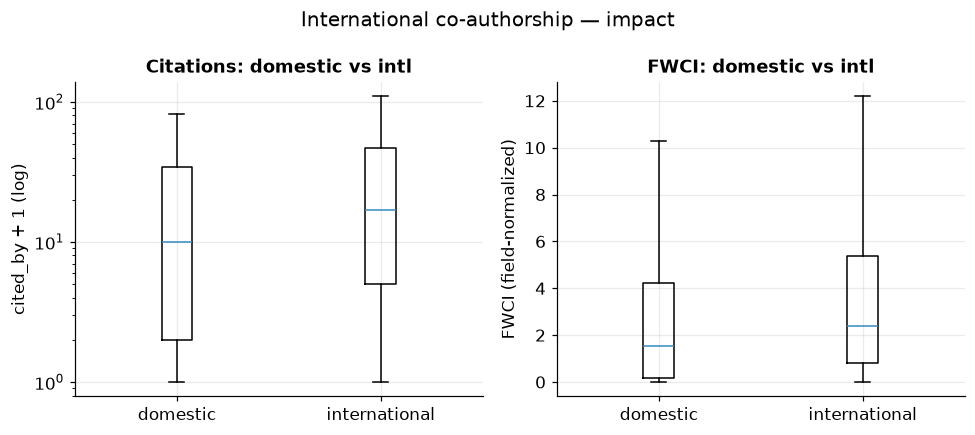

In [30]:
# ② インパクト: 被引用 と FWCI を「国内 vs 国際」で比較（分布が歪むので箱ひげ＋中央値）。
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

# 左: 被引用数。0を含み裾が長いので +1 して対数軸。外れ値(showfliers=False)は隠して箱を見やすく。
ax[0].boxplot([dom_c + 1, itl_c + 1], showfliers=False, tick_labels=['domestic', 'international'])
ax[0].set_yscale('log'); ax[0].set_title('Citations: domestic vs intl'); ax[0].set_ylabel('cited_by + 1 (log)')

# 右: FWCI（分野・年で正規化済み。1.0=世界平均）。正規化済みなので対数にせず素で比較。
ax[1].boxplot([dom_f, itl_f], showfliers=False, tick_labels=['domestic', 'international'])
ax[1].set_title('FWCI: domestic vs intl'); ax[1].set_ylabel('FWCI (field-normalized)')

fig.suptitle('International co-authorship — impact')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_intl_b_impact.pdf'); plt.show()

### ③ 何が国際共著率を左右するか

「どんな論文が国際共著になりやすいか」を、2つの要因から探ります。

- **左：国別の国際共著率** … 1論文は複数国にまたがるので、`explode('countries')` で **1行=「論文×国」**に展開します。そのうえで国ごとに `intl` の平均（＝その国の論文が国際共著だった割合）と件数 `n` を集計。少数の論文しかない国はノイズになるので `n >= 200` に限定し、率の高い上位12か国を横棒で表示します。
- **右：チームサイズとの関係** … 著者数 `n_authors` を `clip(1, 10)`（10 = 10人以上）に丸め、著者数ごとの国際共著率を折れ線にします。著者が多い論文ほど国際共著になりやすいか、を見ます。

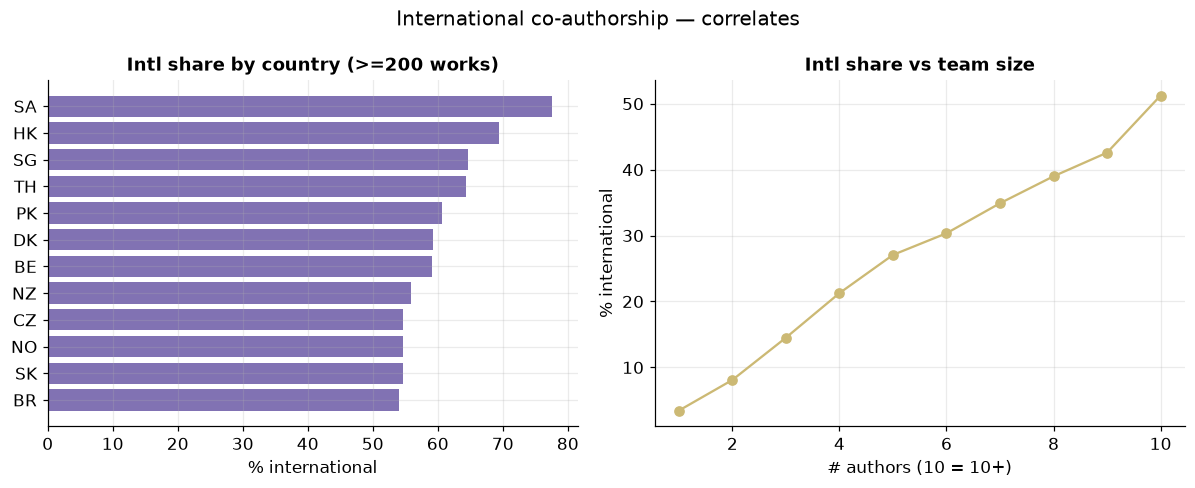

In [31]:
# ③ 相関要因: 国別の国際共著率 と チームサイズとの関係
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# 左: 1論文=複数国なので explode で「論文×国」に展開し、国ごとに intl の平均(=その国の国際共著率)を出す。
ce = w.explode('countries')
g = ce.groupby('countries').agg(intl=('intl', 'mean'), n=('intl', 'size'))
g = g[g['n'] >= 200].sort_values('intl').tail(12)   # 論文200件以上の国に限り、率の上位12を表示
ax[0].barh(g.index, g['intl'] * 100, color='#8172B3')
ax[0].set_title('Intl share by country (>=200 works)'); ax[0].set_xlabel('% international')

# 右: 著者数を1〜10に丸め(10=10人以上)、著者数ごとの国際共著率(intlの平均)を見る。
w['team'] = w['n_authors'].clip(lower=1, upper=10)
ts = w.groupby('team')['intl'].mean() * 100
ax[1].plot(ts.index, ts.values, marker='o', color='#CCB974')
ax[1].set_title('Intl share vs team size'); ax[1].set_xlabel('# authors (10 = 10+)'); ax[1].set_ylabel('% international')

fig.suptitle('International co-authorship — correlates')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_intl_c_correlates.pdf'); plt.show()

**結果の読み方（①②③のまとめ）:**

- **国際共著は増加傾向**（①左）… 近年ほど、関与国が2か国以上の論文の割合が上がっています。ただし関与国数の分布（①右）は依然として1〜2か国が大半で、多国間の大型共著はまれです。
- **国際共著ほど高インパクト**（②）… 被引用の中央値も FWCI も、国際共著群の方が高い傾向。歪んだ分布なので平均ではなく**中央値・箱ひげ**で比べているのがポイントです。
- **チームが大きいほど国際化**（③右）… 著者数が増えるほど国際共著率が上がります。大人数の研究は複数国にまたがりやすい、という直感どおりの関係です。
- **国・地域差**（③左）… 研究規模の小さい国・地域ほど国際共著率が高く、自国内で研究が完結しやすい大国ほど低い傾向。

> **注意（因果ではなく相関）:** ここでの「国際/国内」は著者所属の**国数だけ**による定義です。国際共著論文の被引用が高いのは、「国際共著そのものの効果」だけでなく、テーマの注目度・資金規模・チームの大きさといった**別の要因（交絡）**が混ざっている可能性があります。「国際共著にすれば引用が増える」と因果として断定はできない点に注意してください。

## 4-2. 国別に見る

§4 の右パネル（上位国の積み上げ）を一歩進めて、**国ごとのインパクト**を比べます。ここでも1論文は複数国にまたがるので、`explode('countries')` で **1行=「論文×国」**に展開してから集計します（＝国際共著論文は関与した各国にカウントされ、国別件数の合計はコーパス全体より多くなります）。

### 4-2a. 国別のインパクト比較

論文数の多い上位10か国について、被引用と FWCI の**分布**を国ごとの箱ひげ図で並べます。

- **被引用（左）** … 歪むので `+1` して**対数軸**。
- **FWCI（右）** … 分野・年で正規化済み（1.0 = 世界平均。破線で表示）なので、そのまま比較します。

両パネルとも**被引用の中央値が高い順**に国を並べ、**同じ国順**にそろえてあるので、左右を見比べやすくなっています。外れ値は `showfliers=False` で隠しているので、**箱（中央50%）の位置**に注目してください。

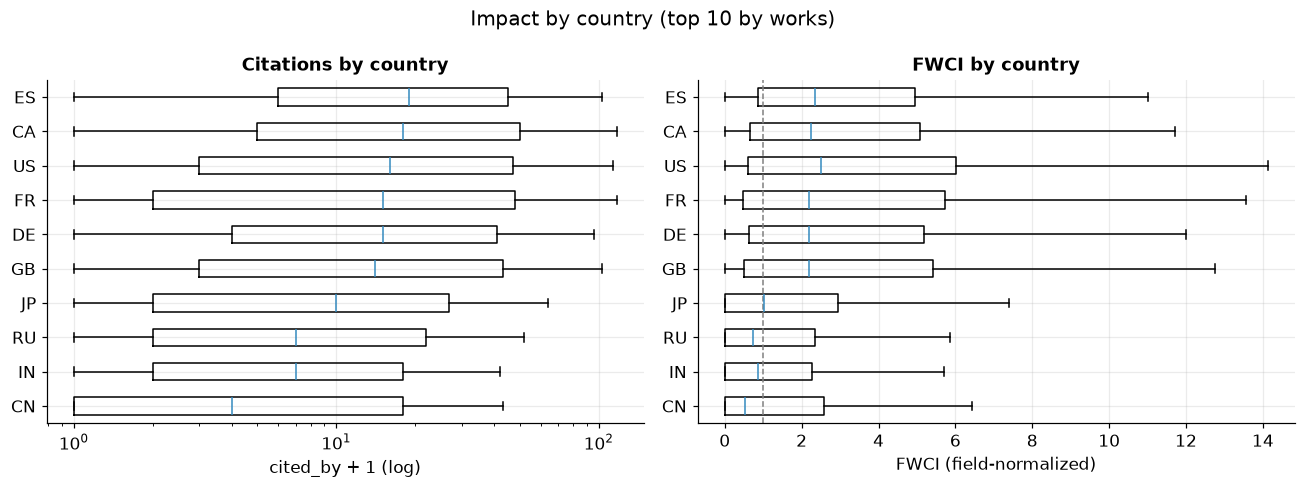

In [32]:
# 上位国ごとに被引用とFWCIの分布を比較（歪むので箱ひげ。被引用は+1して対数軸）。
N = 10
cc = works_df.explode('countries').dropna(subset=['countries'])    # 1行=「論文×国」に展開（国欠損は除外）
top_n = cc['countries'].value_counts().head(N).index.tolist()      # 論文数の多い上位N国
cc = cc[cc['countries'].isin(top_n)]                               # 上位N国だけに絞る
# 左右で国順をそろえるため、被引用の中央値の昇順で国の並びを決める。
order = cc.groupby('countries')['cited_by_count'].median().reindex(top_n).sort_values().index.tolist()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
# 左: 被引用（+1して対数軸、横向き箱ひげ vert=False で国名を読みやすく）
ax[0].boxplot([cc.loc[cc['countries'] == c, 'cited_by_count'] + 1 for c in order],
              showfliers=False, tick_labels=order, vert=False)
ax[0].set_xscale('log'); ax[0].set_title('Citations by country'); ax[0].set_xlabel('cited_by + 1 (log)')
# 右: FWCI（正規化済みなので素で比較。1.0=世界平均の破線）。左と同じ国順。
ax[1].boxplot([cc.loc[cc['countries'] == c, 'fwci'].dropna() for c in order],
              showfliers=False, tick_labels=order, vert=False)
ax[1].axvline(1.0, color='grey', ls='--', lw=1)   # 世界平均 1.0 の基準線
ax[1].set_title('FWCI by country'); ax[1].set_xlabel('FWCI (field-normalized)')
fig.suptitle(f'Impact by country (top {N} by works)')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_by_country_impact.pdf'); plt.show()

**結果の読み方:**

- **論文数が多い国＝インパクトが高い国、とは限りません。** 生の被引用（左）でも正規化済みの FWCI（右）でも、国ごとに箱の位置に差があり、産出量の順位とインパクトの順位は一致しません。
- **FWCI の破線（1.0＝世界平均）が基準です。** 箱が破線より右にある国は、その分野・年の世界平均を上回るインパクトを出している、と読めます。
- 生の被引用（左）は論文の古さや規模の影響を受けますが、FWCI（右）はそれを補正しているので、**国どうしの公平な比較には右パネルの方が適しています**。

## 5. テキスト埋め込みと KNN（OpenAI text-embedding-3）

ここまでは引用や国といった「数値・カテゴリ」を見てきました。§5 では論文の**中身（タイトル＋抄録）**を手がかりに、「意味的に似ている論文」を探します。

- **埋め込み（embedding）とは** … 文章を、意味を反映した**数百次元の数値ベクトル**に変換する技術です。ここでは `text-embedding-3-small` を使い、各論文を **256次元**のベクトルにします。意味の近い論文どうしはベクトルも近くなります。
- **cosine 類似度と KNN** … 2本のベクトルの「向きの近さ」を測るのが **cosine 類似度**（1に近いほど似ている）。ある論文に最も近いベクトルを持つ論文を探せば、それが**意味的な近傍（K-Nearest Neighbors）**です。**この埋め込みは 04 の俯瞰地図でも再利用します。**

**行ズレを防ぐ工夫（OpenAlex ID で対応づけ）:** 埋め込みは `embeddings.npz` に `ids`（各ベクトルの `short_id`）と `vecs`（ベクトル本体）を一緒に保存し、読み込み時は `short_id` をキーに `works_df` の行順へ**整列**します。こうしておくと、`works.parquet` を並べ替えたり取り直したりしても対応がずれません。ファイルがあればそれを使い、無ければ被引用上位 `EMB_N` 件を埋め込んで保存します（`OPENAI_API_KEY` が必要）。

In [33]:
EMB_N = 30000                          # 埋め込みが無いとき、被引用上位 EMB_N 件を新規に埋め込む
EMB_PATH = f'{DATA_DIR}/embeddings.npz'

# OpenAI APIキーは環境変数 OPENAI_API_KEY から読み込みます（未設定なら埋め込みセルはスキップ）。
# 実行前に環境変数を設定するか、次行のコメントを外してキーを直接入れてください:
# os.environ['OPENAI_API_KEY'] = 'sk-...'

def load_embeddings(path, df, id_col='short_id'):
    """ID付き埋め込みを読み込み、df の行順に整列して返す。
    返り値 emb[i] は df の i 行目に対応（埋め込みが無い行は NaN）。mask は計算済み行の True/False。"""
    z = np.load(path, allow_pickle=True)
    ids, vecs = z['ids'].astype(str), z['vecs']        # ids=各ベクトルの short_id, vecs=埋め込み行列
    row_of = {sid: i for i, sid in enumerate(ids)}     # short_id -> vecs の行番号 の辞書
    pos = df[id_col].map(row_of)                       # df の各行 -> vecs の行番号（無ければ NaN）
    mask = pos.notna().to_numpy()                      # 埋め込みがある行だけ True
    emb = np.full((len(df), vecs.shape[1]), np.nan, dtype=vecs.dtype)  # まず全行 NaN で用意
    emb[mask] = vecs[pos[mask].astype(int).to_numpy()]  # 対応する行にだけベクトルを埋める
    return emb, mask

emb, emb_mask = None, None
if os.path.exists(EMB_PATH):
    # 既存の埋め込みを読み込み、short_id で works_df に整列する。
    emb, emb_mask = load_embeddings(EMB_PATH, works_df)
    print(f'loaded embeddings: {emb.shape} / 計算済み {int(emb_mask.sum()):,} 行（works_df と short_id で対応）')
elif os.getenv('OPENAI_API_KEY'):
    # 埋め込みが無ければ、被引用上位 EMB_N 件を OpenAI API で埋め込んで保存する。
    from openai import OpenAI
    client = OpenAI()
    sub = works_df.head(EMB_N)
    # タイトルと抄録を連結し、長すぎる入力は2000文字で打ち切る。
    texts = (sub['title'].fillna('') + '. ' + sub['abstract'].fillna('')).str.slice(0, 2000).tolist()
    vecs = []
    BATCH = 100
    for i in range(0, len(texts), BATCH):   # API 呼び出しは100件ずつのバッチで
        resp = client.embeddings.create(model='text-embedding-3-small', dimensions=256, input=texts[i:i + BATCH])
        vecs += [d.embedding for d in resp.data]
    vecs = np.asarray(vecs, dtype=np.float32)
    # OpenAlex ID(short_id) を添えて保存 -> 行がずれても short_id で再整列できる。
    np.savez(EMB_PATH, ids=sub['short_id'].to_numpy().astype(str), vecs=vecs)
    emb, emb_mask = load_embeddings(EMB_PATH, works_df)
    print(f'computed & saved embeddings: {vecs.shape} -> {EMB_PATH}')
else:
    print('OPENAI_API_KEY 未設定のため埋め込みをスキップします。')

loaded embeddings: (109897, 256) / 計算済み 30,000 行（works_df と short_id で対応）


**次のセルでやること:** 用意した埋め込みを使って、**被引用が最大の論文に意味的に近い論文トップ6**を探します。手順は「①各ベクトルを長さ1に正規化 → ②検索したい論文（クエリ）との cosine 類似度を全件ぶん計算 → ③自分自身を除いて類似度の高い順に並べる」です。ベクトルを正規化してから内積をとると、それがそのまま cosine 類似度になります。

In [34]:
# 被引用最大の論文に「意味的に近い」論文を cosine類似度で検索（emb は works_df と short_id で整列済み）。
if emb is not None:
    query_row = int(np.argmax(emb_mask))               # 最初の計算済み行（= 被引用最大の論文。works_df は被引用降順）
    rows = np.where(emb_mask)[0]                        # 埋め込みが計算済みの行だけを検索対象にする
    M = emb[rows] / np.linalg.norm(emb[rows], axis=1, keepdims=True)   # 各ベクトルを長さ1に正規化
    q = emb[query_row] / np.linalg.norm(emb[query_row])               # クエリ論文のベクトルも正規化
    sims = M @ q                                        # 正規化済み同士の内積 = cosine類似度
    order = np.argsort(sims)[::-1][1:7]                 # 類似度の高い順。先頭(=自分自身)を除いた上位6件
    neighbors = rows[order]
    print('Query:', works_df.iloc[query_row]['title'])
    out = works_df.iloc[neighbors][['title', 'publication_year', 'cited_by_count']].copy()
    out['similarity'] = sims[order].round(3)           # 参考として類似度も表示
    display(out)
else:
    print('埋め込みが無いためKNNをスキップします。')

Query: Cleavage of Structural Proteins during the Assembly of the Head of Bacteriophage T4


,title,publication_year,cited_by_count,similarity
9,Cleavage of structural proteins during the ass...,1970,5676,0.971
4384,Cleavage of head and tail proteins during bact...,1973,124,0.852
5571,Correlation between structural transformation ...,1976,105,0.840
12683,Assembly of bacteriophage T4 head-related stru...,1978,54,0.832
19566,Assembly of bacteriophage T4 head-related stru...,1980,35,0.832
16793,Molecular assembly and structure of the bacter...,2016,42,0.811


**結果の読み方:** クエリはバクテリオファージ T4 の頭部タンパク質に関する超有名論文（Laemmli 1970）です。近傍として返ってきた6件は、いずれも**ファージの頭部・尾部タンパク質の切断や構造アセンブリ**を扱う論文で、テーマがぴったり一致しています。しかも被引用数はバラバラ（5,676〜35）で出版年も1970〜2016年と幅広い——つまりこの検索は**引用関係や年代ではなく、あくまで「意味（中身）の近さ」で論文を集めている**ことが分かります。キーワード検索では拾いにくい類似研究を見つけられるのが、埋め込みの強みです。

## 6. 新興フレーズ分析（N-gram）

「この分野で**最近になって急に使われ始めた言葉**は何か」を、機械的に見つけます。研究のホットトピックの移り変わりを、テキストから直接とらえる試みです。

- **N-gram とは** … 連続する N 個の単語のまとまり。ここでは 2〜3 語（bi-gram / tri-gram、例: "machine learning", "antimicrobial resistance amr"）を対象にします。
- **やり方** … 年ごとに、タイトル＋抄録に登場するフレーズを数え（各年で何本の論文にそのフレーズが出たか）、**近年になって初めて増えたフレーズ**を抽出します。`works_df` をそのまま年で分けて使うだけで、追加のデータ取得は不要です。

なお、出版社の定型文（"published", "copyright" など）は内容と無関係なノイズになるので、ストップワードとして除外します。

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

# 出版社の定型文など、内容と無関係なノイズ語。英語ストップワードに追加して除外する。
BOILER = {'american', 'physical', 'society', 'published', 'copyright', 'rights', 'reserved',
          'elsevier', 'springer', 'wiley', 'author', 'authors', 'abstract', 'http', 'https', 'www', 'doi', 'xmlns', 'mml', 'mi', 'mo', 'mn', 'mrow', 'math', 'org'}
stop = list(CountVectorizer(stop_words='english').get_stop_words()) + list(BOILER)
# 2〜3語のフレーズを対象。min_df=3 で3論文未満のまれな語を捨て、token_pattern で英字2文字以上の語だけ拾う。
vec = CountVectorizer(ngram_range=(2, 3), stop_words=stop, min_df=3, token_pattern=r'(?u)\b[a-z][a-z]+\b')

phrase_year = {}        # phrase -> {year: そのフレーズが出た論文数(doc_freq)}
phrase_first = {}       # phrase -> (初出年, その年の代表行)
for year in range(2010, 2025):
    sub = works_df[works_df['publication_year'] == year]  # その年の全件（サンプリングしない）
    docs = (sub['title'].fillna('') + '. ' + sub['abstract'].fillna('')).tolist()
    if len(docs) < 5:                     # 論文が少なすぎる年はスキップ
        continue
    m = vec.fit_transform(docs)           # 文書×フレーズ の出現回数行列
    terms = vec.get_feature_names_out()
    freq = (m > 0).sum(axis=0).A1         # 各フレーズが「何本の論文に出たか」（回数でなく文書頻度）
    for t, f in zip(terms, freq):
        phrase_year.setdefault(t, {})[year] = int(f)
        phrase_first.setdefault(t, (year, sub.iloc[0]))

# 新興フレーズ = 初出が2015年以降 かつ 2024年に4本以上に出ている もの。
emerging = pd.DataFrame([
    {'phrase': t, 'first_year': min(c), 'last_count': c.get(2024, 0), 'total': sum(c.values())}
    for t, c in phrase_year.items() if min(c) >= 2015 and c.get(2024, 0) >= 4
]).sort_values(['last_count', 'total'], ascending=False).reset_index(drop=True)   # 直近の勢い順に並べる
print(len(emerging), 'emerging phrases')
display(emerging.head(15))

13124 emerging phrases


,phrase,first_year,last_count,total
0,resistance amr,2017,76,228
1,antimicrobial resistance amr,2017,73,222
2,defense systems,2015,60,198
3,multidrug resistant mdr,2015,57,250
4,resistant infections,2016,51,202
5,poses significant,2023,45,51
6,public review,2023,39,57
7,reviewer public,2023,39,55
8,reviewer public review,2023,39,55
9,therapy promising,2015,38,139


**結果の読み方:**

- 抽出された新興フレーズの上位には、**抗菌薬耐性（antimicrobial resistance / amr, multidrug resistant mdr）**、**防御システム（defense systems）**、**機械学習（machine learning）**、**メタゲノム由来ゲノム（metagenome assembled genomes）**などが並びます。近年この分野で注目が高まっているテーマが、テキストからそのまま浮かび上がっています。
- 一方で "public review" / "reviewer public" のような**中身とは関係ないフレーズ**も混ざっています。これは近年の抄録に査読コメントなどの定型文が入り込んだ結果で、`BOILER`（除外語）で完全には取りきれなかったノイズです。**自動抽出の結果は鵜呑みにせず、意味のあるフレーズかを目で確認する**ことが大切だと分かります。

### 6-1. 年次トレンドとヒートマップ

抽出した新興フレーズが、実際に**どう増えてきたか**を2枚で可視化します。

- **折れ線** … 上位8フレーズについて、各年で何本の論文に出たかを重ねて描きます。急に立ち上がったフレーズが一目で分かります。
- **ヒートマップ** … 上位20フレーズ（縦）× 年（横）を、色の濃さ（＝出現論文数）で表します。フレーズごとの「盛り上がった時期」を俯瞰できます。

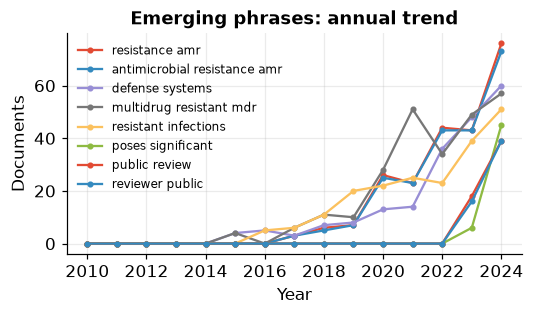

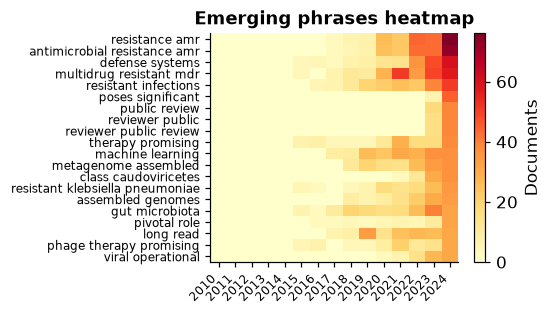

In [37]:
years = list(range(2010, 2025))

# 折れ線: 上位8フレーズの年次推移（各年の出現論文数。データの無い年は 0）。
fig, ax = plt.subplots(figsize=(5, 3))
for p in emerging.head(8)['phrase']:
    ax.plot(years, [phrase_year[p].get(y, 0) for y in years], marker='o', markersize=3, label=p)
ax.set_title('Emerging phrases: annual trend'); ax.set_xlabel('Year'); ax.set_ylabel('Documents')
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_emerging_phrases.pdf'); plt.show()

# ヒートマップ: 上位20フレーズ(行) × 年(列) の出現論文数を色の濃さで表す。
top20 = emerging.head(20)['phrase'].tolist()
heat = np.array([[phrase_year[p].get(y, 0) for y in years] for p in top20])
fig, ax = plt.subplots(figsize=(5, 3))
im = ax.imshow(heat, aspect='auto', cmap='YlOrRd')   # 濃いほど多くの論文に出現
ax.set_xticks(range(len(years))); ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(top20))); ax.set_yticklabels(top20, fontsize=8)
ax.set_title('Emerging phrases heatmap'); ax.grid(False)
fig.colorbar(im, ax=ax, label='Documents')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/02_emerging_heatmap.pdf'); plt.show()

**結果の読み方:** 折れ線・ヒートマップとも、多くのフレーズが**2015年ごろまではほぼ0で、近年に向かって急に立ち上がる**形になっています。これが「新興フレーズ」の典型的なシグネチャです。ヒートマップの右側（近年）ほど色が濃くなる行が、いま伸びているトピックにあたります。こうした可視化は、分野の関心が時間とともにどこへ移っているかを一望するのに役立ちます。

## まとめ

このノートブックで学んだこと（サイエンス・オブ・サイエンスの基本の型）:

- **基礎統計** … 被引用は強く右に歪む（平均 ≫ 中央値）。近年の論文ほど引用は貯まりにくい（**時間効果**）ので、年をまたいだ生の被引用比較は禁物。著者数と OA 率は年々上昇。
- **引用の偏り** … ジニ係数は 0.8 超。**被引用をそのまま平均する分析の危うさ**を数字で確認しました。裾の形は「見た目」ではなく Clauset 法で検定し、「指数分布ではない重い裾だが、べき乗則とは断定できない」ことを確かめました。
- **国際共著** … 関与国2か国以上の論文は増加傾向で、被引用・FWCI とも高い傾向。ただし**相関であって因果ではない**点に注意。
- **テキスト分析** … タイトル＋抄録の埋め込みで「意味的に近い論文」を検索し、N-gram で「近年増えたフレーズ」を抽出しました。自動抽出にはノイズも混じるため、目視確認が大切。
- **共通の教訓** … 偏った分布・時間効果・交絡（相関≠因果）——この3つを意識するだけで、引用データの読み違いを大きく減らせます。

ここで使ったデータ `works.parquet` / `paper_authors.parquet` は [01. OpenAlex API アクセス入門](01_openalex_api_access.ipynb) が取得・保存したものです。次は著者単位の分析（**03 研究者の将来予測**）に進みます。